In [18]:
from langchain_groq import ChatGroq
from dotenv import find_dotenv , load_dotenv
from langchain_core.prompts import ChatPromptTemplate

import os

load_dotenv(find_dotenv(),override=True)

if os.environ['GROQ_API_KEY']:
    print('Grok Api Key found sucessfully')
else:
    print('Grok API key is missing ')

Grok Api Key found sucessfully


In [19]:
llm=ChatGroq(model="llama-3.3-70b-versatile")

# **Pydantic LLM Schema**

In [20]:
from pydantic import BaseModel,Field

from typing import TypedDict,List

class llm_schema(BaseModel):
    tasks:List[str]=Field(...,description="A list of task to be performed by the worker ")

llm_with_schema=llm.with_structured_output(llm_schema)

# **Graph Schema**

In [21]:


class graph_schema(TypedDict):
        tasks:List[str]
        querry:str
        results:List[str]
        summary:str    

# **Orchestrator**

In [22]:

def orchestrator_node(state:graph_schema)->graph_schema:
    user_query=state['querry']
    prompt=ChatPromptTemplate([
        ('system',"You are an Orchestrator that breaks down user querry into tasks for the worker"),
        ("human",f"User query : {user_query}. Please Generate one prompt per task for the worker nodes to complete , Return Tasks in List Format")
    ])
    chain=prompt | llm_with_schema
    response=chain.invoke({"querry":user_query})
    state['tasks']=response.tasks

    return state

In [23]:
# Worker Node for mini tasks
def exectue(querry:str):
    response=llm.invoke(f'Please execute this task {querry}')
    return response.content

In [24]:
# Worker Node Main that allows multi threading

from concurrent.futures import ThreadPoolExecutor

def worker_node(state:graph_schema)-> graph_schema:
    tasks=state['tasks']
    results=[]

    with ThreadPoolExecutor (max_workers=len(tasks)) as executor:
        results_futures=executor.map(exectue,tasks)
        for result in results_futures:
            results.append(result)
    
    state['results']=results
    return state

In [25]:
# Collector Node

def collector_node(state:graph_schema)-> graph_schema:
    results=state['results']
    prompt=ChatPromptTemplate([
        ('system',"You are a collector that summerizes that results from the worker."),
        ('human',f"Here are the results from that worker: {results}. Summerize them in conise manner ")

    ])
    chain=prompt | llm
    summary=chain.invoke({"results":results})

    state['summary']=summary

    return state


# **Graph creation and execution**

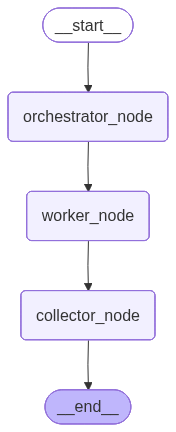

In [26]:
from langgraph.graph import StateGraph,START,END

graph=StateGraph(state_schema=graph_schema)

graph.add_node("orchestrator_node",orchestrator_node)
graph.add_node('worker_node',worker_node)
graph.add_node("collector_node",collector_node)

graph.add_edge(START,"orchestrator_node")
graph.add_edge("orchestrator_node","worker_node")
graph.add_edge("worker_node",'collector_node')

complex_graph=graph.compile()

from IPython.display import Image
Image(complex_graph.get_graph().draw_mermaid_png())


In [27]:
for chunk in complex_graph.stream(
    {
    "querry":"What is the Capital of India and what is its population how much polultaion in kashmir india?",
    "tasks":[],
    "results":[],
    "summary":"",
    },
    stream_mode="updates"
    ):  
    print(chunk)

{'orchestrator_node': {'tasks': ['Find the capital of India', 'Find the population of India', 'Find the population of Kashmir, India'], 'querry': 'What is the Capital of India and what is its population how much polultaion in kashmir india?', 'results': [], 'summary': ''}}
{'worker_node': {'tasks': ['Find the capital of India', 'Find the population of India', 'Find the population of Kashmir, India'], 'querry': 'What is the Capital of India and what is its population how much polultaion in kashmir india?', 'results': ['The capital of India is New Delhi.', "The population of India is approximately 1.393 billion people, according to the United Nations estimates for 2022. This makes India the second-most populous country in the world, after China.\n\nHere is a breakdown of India's population:\n\n* Total population: 1,393,409,033 (2022 estimate)\n* Male population: 714,555,111 (2022 estimate)\n* Female population: 678,853,922 (2022 estimate)\n* Urban population: 483,098,953 (2022 estimate)\

In [29]:
from IPython.display import Markdown, display

response=complex_graph.invoke({
    "querry":"What is the Capital of India and what is its population how much polultaion in kashmir india?",
    "tasks":[],
    "results":[],
    "summary":"",
    },)
display(Markdown(f"""
### 📱 Tasks: `{response['tasks']}`
### 🏷️ Results: {response['results']}
### 🏷️ Summary: 
---
{response['summary']}
"""))


### 📱 Tasks: `['Find the capital of India', 'Find the population of India', 'Find the population of Kashmir, India']`
### 🏷️ Results: ['The capital of India is New Delhi.', "The population of India is approximately 1.417 billion people, according to the United Nations estimates for 2023. However, please note that population figures can vary depending on the source and date.\n\nAs of the 2011 census, the population of India was 1.21 billion. The country has experienced significant population growth since then, with an average annual growth rate of 1.2%.\n\nHere is a rough breakdown of India's population:\n\n* Total population: 1.417 billion (2023 estimate)\n* Urban population: 483 million (approximately 34% of the total population)\n* Rural population: 934 million (approximately 66% of the total population)\n* Male population: 726 million (approximately 51% of the total population)\n* Female population: 691 million (approximately 49% of the total population)\n\nPlease note that these numbers are estimates and may have changed slightly since the last official census in 2011.", "The population of Kashmir, India is a bit complex to determine as Kashmir is a disputed region and the population figures may vary depending on the source. However, I can provide you with the population figures for the Indian-administered region of Jammu and Kashmir, which includes the Kashmir Valley.\n\nAccording to the 2011 Census of India, the population of Jammu and Kashmir is approximately 12.5 million people. The population density is around 56 people per square kilometer.\n\nHere is a breakdown of the population of Jammu and Kashmir by district:\n\n* Srinagar district: 1,269,751\n* Anantnag district: 1,078,692\n* Pulwama district: 570,060\n* Baramulla district: 1,008,039\n* Budgam district: 735,753\n* Kupwara district: 870,354\n* Bandipora district: 392,232\n* Ganderbal district: 297,003\n* Shopian district: 265,960\n* Kulgam district: 423,181\n* Reasi district: 314,667\n* Ramban district: 283,313\n* Doda district: 409,936\n* Udhampur district: 555,357\n* Kathua district: 615,711\n* Jammu district: 1,526,406\n* Samba district: 318,898\n* Rajouri district: 642,415\n* Poonch district: 476,835\n\nPlease note that these figures are based on the 2011 Census, and the population may have changed since then due to various factors such as population growth, migration, and other demographic changes.\n\nIt's also important to note that the population of the Pakistan-administered region of Kashmir, also known as Azad Kashmir and Gilgit-Baltistan, is not included in these figures. The population of Azad Kashmir is approximately 4.5 million people, and the population of Gilgit-Baltistan is around 2 million people. However, these figures are not officially recognized by the Indian government, and the region is considered disputed."]
### 🏷️ Summary: 
---
content="Here's a concise summary of the results:\n\n1. **Capital of India**: New Delhi\n2. **Population of India**:\n\t* Total: 1.417 billion (2023 estimate)\n\t* Urban: 483 million (34%)\n\t* Rural: 934 million (66%)\n\t* Male: 726 million (51%)\n\t* Female: 691 million (49%)\n3. **Population of Kashmir (Jammu and Kashmir)**:\n\t* Total: 12.5 million (2011 census)\n\t* Breakdown by district provided, with Srinagar being the most populous district (1,269,751)\n\nNote: The population figures are estimates and may have changed since the last official census in 2011. The population of the Pakistan-administered region of Kashmir is not included in these figures." additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 172, 'prompt_tokens': 743, 'total_tokens': 915, 'completion_time': 0.449915481, 'completion_tokens_details': None, 'prompt_time': 0.057222667, 'prompt_tokens_details': None, 'queue_time': 0.15758373, 'total_time': 0.507138148}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019dce33-e373-7f21-9784-01af5668773e-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 743, 'output_tokens': 172, 'total_tokens': 915}
